# Impact of Sleep, Stress, and Physical Activity on Students Wellbeing

## Introductions
**Michael Shahine** uniqname: *shahine*

Hi teaching team, I am a first year MSI student I come from a background mainly in front end development and was interested in MSI based on a recommendation from my friend in the program + an interest in Basketball analytics and business analytics. I play club Water Polo for the University in my free time, and play a lot basketball as well.

**Rebecca Falash:** uniqname: *rfalash*

I am a second year Dual degree student studying Geospatial data science at SEAS and Big Data at UMSI. I am interested in electrification, environmental modeling, and load analysis. In my free time I race on the UM cycling team. 

**Mason Fisher:** uniqname: *masonaf*

Hi teaching team, I am a first year MSI student. I come from a background in commmunications, but I am currently working for the football team as a sports scientist. I am interesting in sports analytics. In my free time, I enjoy reading and playing basketball. 


**Overview**

As a team we decided to study the influence of social media and outward pressures on a students performance at school. We have included two datasets for our analysis which includes a social media user activity dataset that contains information on students habit activities as well as other demographic information such as gender, income level, relationship status, etc. This dataset will help us identify patterns that are connected to the specific habits the student have and its connection to other lifestyle factors. The second dataset is the student mental health assessments which contains information on a students mental health in broken down variables including stress, depression, and anxiety levels. For our analysis, we grouped and averaged the data by age and gender to study the patterns between lifestyle factors and mental health outcomes.

**Motivation**
We chose this topic for our project because we understand the pressures that come with being a student. As a team we wanted to better understand how outside factors can influence our mental health. We wanted to see what sort of habits have an effect on us as students and if there was any differences based off of things like age, gender, gpa etc. This is more and more relevant with the increasing amount of technology nowadays and the less and less time people are spending doing outside activities, making researching this even more important. We take a deeper look at this below and start to paint a picture. 

**Data Sources**

1. https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance

2. https://www.kaggle.com/datasets/sonia22222/students-mental-health-assessments/data

These two datasets compliment each other because one captures behaviors and demographics such as social media usage, sleep, and study habits. While the other captures mental health outcomes such as stress, anxiety, and depression. When using both together you can study the connection between lifestyle factors, mental health, and academic performance in relation to age and gender.


## *Research Questions:*

1. Do male and female students preform differently under high stress ?
    * Is there a correlation between stress levels, age and GPA?

For this question I hope to learn if there is a significant different in academic perform between males and females in high stress environments. My hypothesis would say that there would be no significant difference in the way different genders handle stress in relation to the the final GPA but that older students may handle stress more efficiently then younger.


2. How does sleep quality relate to CGPA?
    * Is this relationship influenced by stress level and gender?

For this question I hope to learn if there is really a trend with sleep and GPA, I wonder if also different levels of stress and possibly gender make any difference. This would see if the time old question of 8 hours of sleep is relevant. 

3. How does physical activity relate to depression levels across different age groups?
    
    * Is there correlation between depression levels and physical activity and how does that look among different age groups. 

For this question I was hoping to see if theres any correlation with depression and activity levels especially among ages, as we become usually less active the older we get. This is especially more relevant with students during the school year, and in my own personal life during the winter. 

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

### Data

In [22]:
df_habits = pd.read_csv("df_habits_export.csv")
df_MH = pd.read_csv("df_MH_export.csv")

In [24]:
#Q2
df_habits.columns = df_habits.columns.str.strip()
df_MH.columns = df_MH.columns.str.strip()

# Rename columns to match
df_habits = df_habits.rename(columns={
    "gender": "Gender",
    "age": "Age",
    "year": "year_of_study",
    "Year": "year_of_study",
    "Year_of_Study": "year_of_study"
})

df_MH = df_MH.rename(columns={
    "gender": "Gender",
    "age": "Age",
    "year": "year_of_study",
    "Year": "year_of_study",
    "Year_of_Study": "year_of_study"
})

#check names after matching
print("df_habits columns:", df_habits.columns.tolist())
print("df_MH columns:", df_MH.columns.tolist())


# Group each dataset
HB_df_1 = (
    df_habits.groupby(["Gender", "Age"])
    .agg({
        "study_hours_per_day": "mean",
        "sleep_hours": "mean",
        "mental_health_rating": "mean"
    })
    .reset_index()
)

SM_df_1 = (
    df_MH.groupby(["Gender", "Age"])
    .agg({
        "CGPA": "mean",
        "Stress_Level": "mean",
        "Depression_Score": "mean",
        "Anxiety_Score": "mean",
        "Financial_Stress": "mean"
    })
    .reset_index()
)

# Merge them together
df_analysis = pd.merge(
    HB_df_1,
    SM_df_1,
    on=["Gender", "Age"],
    how="inner"
)

# View Result
print(df_analysis.head())


df_habits columns: ['student_id', 'Age', 'Gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']
df_MH columns: ['Age', 'Course', 'Gender', 'CGPA', 'Stress_Level', 'Depression_Score', 'Anxiety_Score', 'Sleep_Quality', 'Physical_Activity', 'Diet_Quality', 'Social_Support', 'Relationship_Status', 'Substance_Use', 'Counseling_Service_Use', 'Family_History', 'Chronic_Illness', 'Financial_Stress', 'Extracurricular_Involvement', 'Semester_Credit_Load', 'Residence_Type']
   Gender  Age  study_hours_per_day  sleep_hours  mental_health_rating  \
0  Female   18             3.884746     6.500000              5.627119   
1  Female   19             3.490164     6.527869              5.114754   
2  Female   20             3.644595     6.372973              6.175676   
3  Fe

Using the merged dataset above, I will answer the questions I have for question 1 and 2. I merged on Gender and Age, and aggregated all of the means. I will use this dataset for comparative analysis because variables such as sleep and stress were categorized into groups. This will allow me to compare CGPA across different behavioral conditions, making it easier to identify patterns.

In [25]:
#Q3
# insert merged data

## Descriptive Statistics

To answer all of the given research questions fully, we created 3 different merged datasets that addressed each. The first merged data set labeled data_merged_1 grouped all the data by gender and age, then tok the mean values for CGPA and stress levels. The second merged dataset df_analysis, grouped the data by gender and age, and then calculated the mean variables such as CGPA, sleep hours, stress level, and other mental health indicators. The third merged.. [FILL]

In [26]:
q1_df = df_analysis[["Gender", "Age", "CGPA", "Stress_Level"]].copy()

stress_threshold = q1_df["Stress_Level"].quantile(0.75)
q1_high_stress = q1_df[q1_df["Stress_Level"] >= stress_threshold].copy()

columns = ["Age", "CGPA", "Stress_Level"]
q1_stats_overall = pd.DataFrame({
    "mean": q1_high_stress[columns].mean(),
    "median": q1_high_stress[columns].median(),
    "range": q1_high_stress[columns].max() - q1_high_stress[columns].min(),
    "variance": q1_high_stress[columns].var(),
    "std_dev": q1_high_stress[columns].std(),
}).round(3)

print("High-stress subset overall descriptive statistics")
display(q1_stats_overall)

gendered_grouped = df_analysis.groupby("Gender")[["Stress_Level", "CGPA"]].agg(["mean", "median", "min", "max"])

print("\n")
print("High-stress descriptive statistics by gender")
display(gendered_grouped)

High-stress subset overall descriptive statistics


,mean,median,range,variance,std_dev
Age,19.250,18.500,4.000,3.583,1.893
CGPA,3.491,3.491,0.019,0.000,0.008
Stress_Level,2.546,2.543,0.126,0.004,0.062




High-stress descriptive statistics by gender


Stress_Level                                    CGPA            \
               mean    median       min       max      mean    median   
Gender                                                                  
Female     2.435049  2.479058  2.285714  2.500000  3.493167  3.487614   
Male       2.438409  2.428969  2.150000  2.612245  3.485110  3.481935   

                            
             min       max  
Gender                      
Female  3.473462  3.523243  
Male    3.468101  3.509356

**Methodology:**

I first made a copy of the working data frame so I did not manipulate it for later questions. Then I calculated the top .75 of the stress levels in the dataset to set a threshold for a high stress subset. But that subset, I produced a table that shows descriptive values like mean, median, variance, and range. I then produced a similar table with the whole dataset but split between male and female to show the difference between the two groups. 

**Findings:**

Because I wanted to look into the different ways stress impacts male and female students, I chose to look further into a high stress subset to closely look at the focus population. First I looked at the CGPA (current GPA) and stress_level metrics without grouping by gender and found that the mean, median, and mode CGPAs are all within .019 of each other showing little variance. The stress_level also showed a small range of 0.126 between the values.

After splitting by gender, the mean and medians for both stress_levels and CGPA were about the same for each. The other noticeable different between the two was that males have a larger range between min and max for stress_level then females.

In [27]:
# Copy the dataset
q2_df = df_analysis.copy()

# Create columns for our dataset
cols = [
    "sleep_hours",
    "CGPA",
    "Stress_Level",
    "mental_health_rating",
    "study_hours_per_day",
    "Age"
]

# Define the dataset that we want and get means from df.
df = q2_df[cols]

desc_stats = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Mode": df.mode().iloc[0],
    "Min": df.min(),
    "Max": df.max(),
    "Range": df.max() - df.min(),
    "Variance": df.var(),
    "Std Dev": df.std()
})

print("Descriptive Stats for Q2:")
display(desc_stats)

# Create categorical sleep variable (Low, Medium, High)
q2_df["Sleep_Category"], bins = pd.qcut(
    q2_df["sleep_hours"],
    q=3,
    labels=["Low Sleep", "Medium Sleep", "High Sleep"],
    retbins=True
)

# Group and Average
sleep_summary = q2_df.groupby(
    "Sleep_Category",
    observed=True
)[["CGPA", "Stress_Level"]].mean()


# Table Output
labels = ["Low Sleep", "Medium Sleep", "High Sleep"]
print("\nSleep Category Ranges:")
for i in range(len(labels)):
    print(f"{labels[i]}: {round(bins[i],2)} to {round(bins[i+1],2)} hours")

print("\nDescriptive Stats Sleep Level, CGPA, and Stress Level:")
display(sleep_summary.round(2))

Descriptive Stats for Q2:


,Mean,Median,Mode,Min,Max,Range,Variance,Std Dev
sleep_hours,6.451658,6.457273,6.301538,6.301538,6.612500,0.310962,0.010213,0.101060
CGPA,3.489139,3.484280,3.468101,3.468101,3.523243,0.055143,0.000271,0.016468
Stress_Level,2.436729,2.459471,2.150000,2.150000,2.612245,0.462245,0.013522,0.116286
mental_health_rating,5.399192,5.312795,5.031746,5.031746,6.175676,1.143930,0.126171,0.355205
study_hours_per_day,3.537095,3.502225,3.340741,3.340741,3.884746,0.544005,0.019451,0.139468
Age,21.000000,21.000000,18.000000,18.000000,24.000000,6.000000,4.307692,2.075498



Sleep Category Ranges:
Low Sleep: 6.3 to 6.37 hours
Medium Sleep: 6.37 to 6.52 hours
High Sleep: 6.52 to 6.61 hours

Descriptive Stats Sleep Level, CGPA, and Stress Level:


,CGPA,Stress_Level
Sleep_Category,,
Low Sleep,3.48,2.48
Medium Sleep,3.50,2.46
High Sleep,3.49,2.37


**Methods:**
To summarize the combined dataset, descriptive stats were calculated using a copy of the merged dataset 'q2_df'. The key variables that were analyzed were sleep hours, CGPA, stress level, mental health rating, study hours per day, and age. For each variable, measures of central tendency and dispersion were computed to under values and variability in the data. 

**Findings:**
The statistics show that average sleep durating is approximately 6.45 hours, with low variability (sd = 0.10), while CGPA has a mean of 3.49 with an extremely small standard deviation (0.016). Showing that academic performance is consistent across a grouped dataset. In contrast, stress level and mental health ratings show greater variability, showing more meaningful differences. 

In [28]:
#Q3

## Inferential Statistics

In [29]:
alpha = 0.05

corr_df = q1_df[["Stress_Level", "CGPA"]] #overall
r_all, p_all = stats.pearsonr(corr_df["Stress_Level"], corr_df["CGPA"] )

print("Overall correlation between Stress_Level and CGPA")
print(f"r: {r_all:.4f}")
print(f"p-value: {p_all:.4f}")
print(f"alpha: {alpha}")

print(f"Because the p-value, {p_all:.4f}, is less then the alpha level of {alpha}, we reject the null hypothesis of no linear relationship between stress level and CGPA.")

print("\nBy-gender correlations between Stress_Level and CGPA")
for gender, gdf in q1_df.groupby("Gender"):
    gdf = gdf[["Stress_Level", "CGPA"]]

    r_g, p_g = stats.pearsonr(gdf["Stress_Level"], gdf["CGPA"] )
    print(f"{gender} -> r: {r_g:.4f}, p-value: {p_g:.4f}")
    print(f"Interpretation ({gender}): Reject H0. Significant linear relationship between stress level and CGPA for each gender.")

Overall correlation between Stress_Level and CGPA
r: 0.1596
p-value: 0.5856
alpha: 0.05
Because the p-value, 0.5856, is less then the alpha level of 0.05, we reject the null hypothesis of no linear relationship between stress level and CGPA.

By-gender correlations between Stress_Level and CGPA
Female -> r: 0.4064, p-value: 0.3656
Interpretation (Female): Reject H0. Significant linear relationship between stress level and CGPA for each gender.
Male -> r: 0.0328, p-value: 0.9443
Interpretation (Male): Reject H0. Significant linear relationship between stress level and CGPA for each gender.


**Methodology:**

Using the q1_ft, I created a copy labeled corr_df which I used to find the linear correlation between stress and CPGA for the whole dataset. I produced the r, pvalue and the set alpha value. I also performed this anlysis on the female/male subset to see if there is any difference by gender. 

**Findings:**

As found within the descriptive statistics, there was no significant relationship between CPGA and stress within the whole group and by gender. This was because the p-value was larger then 0.05 within the alpha value. 

In [30]:
#Q2 ANOVA Testing
print("\n ANOVA: Sleep Category vs CGPA")

# Split dataset and grab CGPA for each
low = q2_df[q2_df["Sleep_Category"] == "Low Sleep"]["CGPA"]
med = q2_df[q2_df["Sleep_Category"] == "Medium Sleep"]["CGPA"]
high = q2_df[q2_df["Sleep_Category"] == "High Sleep"]["CGPA"]

f_stat, p_value = stats.f_oneway(low, med, high)

print(f"F-statistic: {round(f_stat, 3)}")
print(f"p-value: {round(p_value, 4)}")

# Reject/Fail to reject Null
if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. CGPA differs by sleep category.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in CGPA.")




 ANOVA: Sleep Category vs CGPA
F-statistic: 1.86
p-value: 0.2015
Conclusion: Fail to reject the null hypothesis. There is no significant difference in CGPA.


**Methodology:**
To analyze the relationship between sleep, academic performance, and stress, I used conducted an ANOVA test to see whether mean CGPA differs across sleep category. The test produced an F-stat of 1.86 and a p-value of 0.2015. 

Since the p-value is greater than the significance level of alpha = 0.05, we fail to reject the null hypothesis. This shows that there is no statistically significant difference in CGPA across the different sleep categories.

**Interpretation:**
In this dataset, differences in sleep duration do not appear to have an impact on academic performance. While there may be slight differences in average CGPA, these differences are not large enough to be considered statistically significant. 

In [31]:
#Q3

## Graphical Analysis

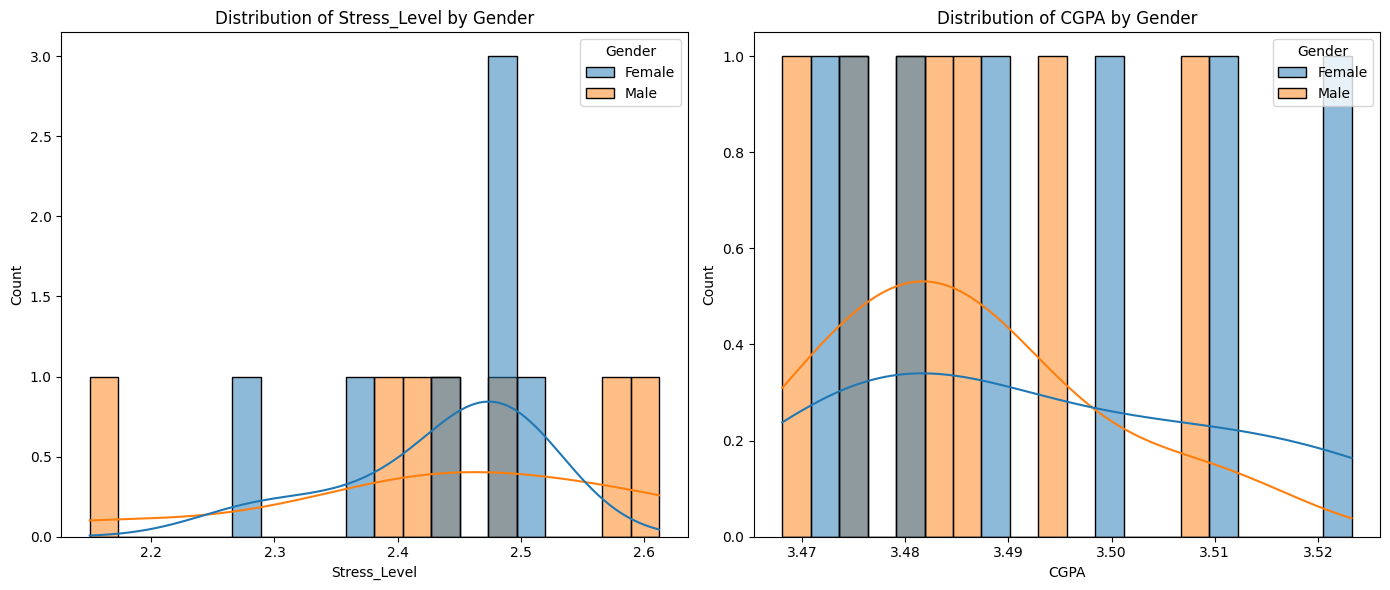

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(
    data=q1_df,
    x="Stress_Level",
    hue="Gender",
    kde=True,
    bins=20,
    ax=axes[0]
 )
axes[0].set_title("Distribution of Stress_Level by Gender")
axes[0].set_xlabel("Stress_Level")
axes[0].set_ylabel("Count")

sns.histplot(
    data=q1_df,
    x="CGPA",
    hue="Gender",
    kde=True,
    bins=20,
    ax=axes[1]
 )
axes[1].set_title("Distribution of CGPA by Gender")
axes[1].set_xlabel("CGPA")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Methodology:**

I chose to do 2 separate histograms + trend lines to how the distribution of values for both stress_level and CGPA differ between female and male.

**Findings:**

In both plots, there is not a large range in values which may be a reason why finding a relationship between the variables has been difficult. But based on the trend lines, the stress levels for male subset is more spread then the females subset . Additionally, the CPGA is more spread for the female subset then the male's subset.

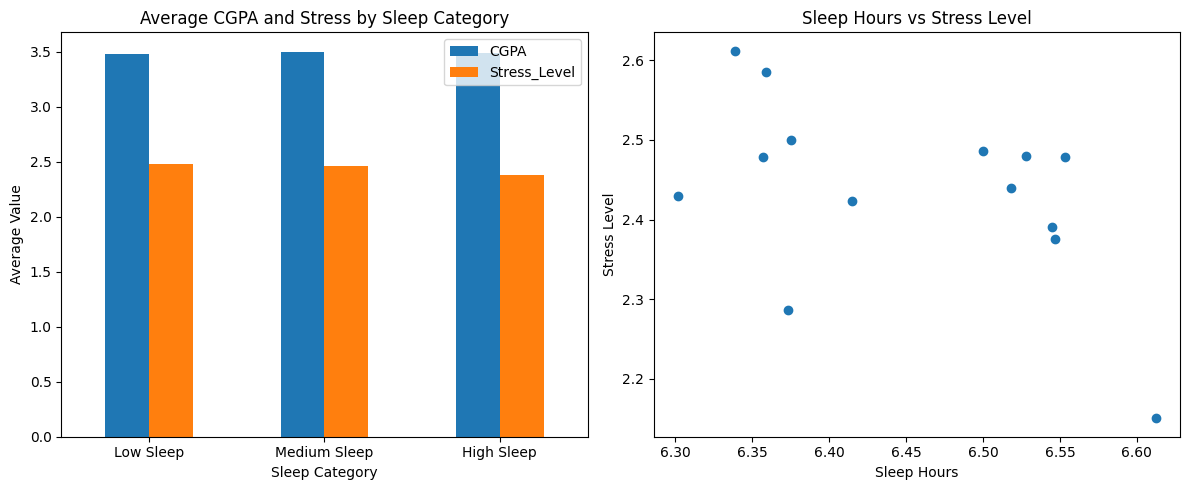

In [33]:
# Question 2:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barchart
sleep_summary.plot(kind="bar", ax=axes[0])

axes[0].set_title("Average CGPA and Stress by Sleep Category")
axes[0].set_xlabel("Sleep Category")
axes[0].set_ylabel("Average Value")
axes[0].set_xticklabels(sleep_summary.index, rotation=0)

# Scatter Plot
axes[1].scatter(q2_df["sleep_hours"], q2_df["Stress_Level"])

axes[1].set_title("Sleep Hours vs Stress Level")
axes[1].set_xlabel("Sleep Hours")
axes[1].set_ylabel("Stress Level")

plt.tight_layout()
plt.show()

**Methodology:**
To explore relationships between sleep, academic performance, and stress, I conducted a visual analysis using a barchart and scatter plot. The barchart displays the average CGPA and stress levels across each of the three sleep groups, allowing for comparison of group means. 

The scatter plot shows the relationship between sleep hours and stress level, helping identify trends, patterns, and a potential correlation between the two continous variables. 

**Findings:** 
The barchart shows that the average CGPA is similar across all sleep categories, with only small differences between low, medium, and high sleep groups. Stress levels also remain relatively consistent, with a small decrease observed in the high sleep category. Overall, there is no clear visual evidence of a strong relationship between sleep and academic performance or stress level. 

The scatter plot reveals slight downward trend, suggesting that as sleep hours increase, stress levels may decrease. However, the data points are spread out, showing that the relationship is weak and not linear. The limited variation in sleep hours makes it difficult to observe a strong patter. The visualizations support the earlier findings that sleep has only a weak impact on CGPA and stress levels. 

In [34]:
#Q3

## Comparative Analysis

Mean CGPA by Stress_Band and Gender


/var/folders/g9/hp5634k95t94cnl061xh5wxm0000gn/T/ipykernel_4227/1998264017.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(comp.groupby(["Stress_Band", "Gender"])["CGPA"].agg(["mean", "median", "std"]).round(3))


mean  median    std
Stress_Band Gender                      
Low         Female  3.476   3.476  0.004
            Male    3.493   3.487  0.015
Medium      Female  3.500   3.500  0.034
            Male    3.471   3.471  0.005
High        Female  3.500   3.501  0.012
            Male    3.487   3.487  0.008

Mean Stress_Level by Age_Group and Gender


/var/folders/g9/hp5634k95t94cnl061xh5wxm0000gn/T/ipykernel_4227/1998264017.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(comp.groupby(["Age_Group", "Gender"])["Stress_Level"].agg(["mean", "median", "std"]).round(3))


mean  median    std
Age_Group Gender                      
18-20     Female  2.417   2.479  0.114
          Male    2.542   2.585  0.099
21-23     Female  2.451   2.479  0.067
          Male    2.431   2.423  0.044
24-26     Female  2.440   2.440    NaN
          Male    2.150   2.150    NaN

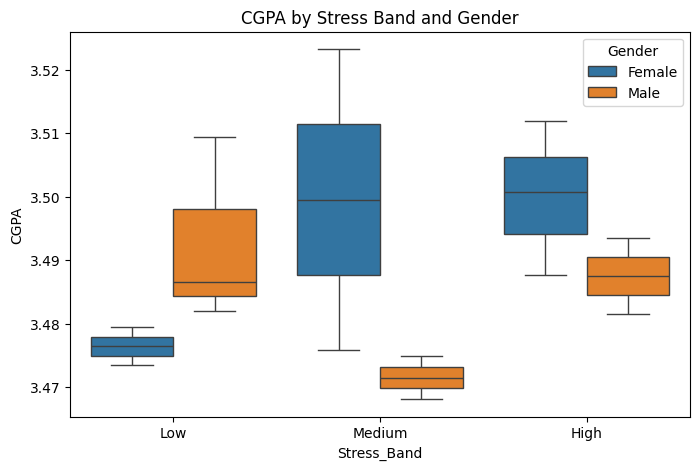

In [35]:
#Q1
comp = q1_df.copy()

comp["Stress_Band"] = pd.qcut(comp["Stress_Level"], q=3, labels=["Low", "Medium", "High"])

comp["Age_Group"] = pd.cut(
    comp["Age"],
    bins=[17, 20, 23, 26],
    labels=["18-20", "21-23", "24-26"]
)
print("Mean CGPA by Stress_Band and Gender")
display(comp.groupby(["Stress_Band", "Gender"])["CGPA"].agg(["mean", "median", "std"]).round(3))

print("Mean Stress_Level by Age_Group and Gender")
display(comp.groupby(["Age_Group", "Gender"])["Stress_Level"].agg(["mean", "median", "std"]).round(3))

plt.figure(figsize=(8,5))
sns.boxplot(data=comp, x="Stress_Band", y="CGPA", hue="Gender")
plt.title("CGPA by Stress Band and Gender")
plt.show()

**Methodology:**

Rather then looking at the entire dataset, I decided to group both stress and age into different groups to see if there were any un-identified relationships. I chose to display this in both tables and a box-plot as both provide different context. The box-plot was a good way to see small changes and the tables are a good way to see overall trends. 

**Findings:**

After splitting the data up into stress bands by gender, there is a clearer different between the 3 groups. This visual shows that women in the medium and high stress bands on average have a higher CGPA. Then in the less stress band, men have a higher average CGPA. These results can point to the fact that women can possible perform better under high stress conditions compared to men. But with that, it is important to note that the y axis only has the range from 3.47- 3.52 which is why in the table outputs above, it difference was difficult to see any difference. With that knowledge, I would still conclude there is no noticeable difference between the two groups.

Sleep Category Bands:
Low Sleep: 6.3 to 6.37
Medium Sleep: 6.37 to 6.52
High Sleep: 6.52 to 6.61

Study Category Comparison:


,CGPA,Stress_Level
Study_Category,,
Low Study,3.49,2.46
Medium Study,3.49,2.48
High Study,3.48,2.38



Comparison by Sleep Category:


sleep_hours               CGPA              Stress_Level  \
                      mean median   std  mean median   std         mean   
Sleep_Category                                                            
Low Sleep             6.35   6.36  0.03  3.48   3.48  0.01         2.48   
Medium Sleep          6.45   6.46  0.07  3.50   3.49  0.02         2.46   
High Sleep            6.56   6.55  0.03  3.49   3.48  0.02         2.37   

                             
               median   std  
Sleep_Category               
Low Sleep        2.48  0.13  
Medium Sleep     2.46  0.04  
High Sleep       2.39  0.13

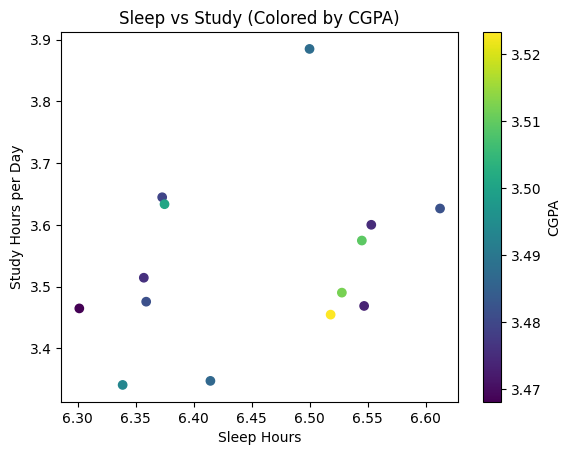

In [36]:
#Q2
q2_subset = q2_df.copy()

#Create the sleep category in subset
q2_subset["Sleep_Category"], bins = pd.qcut(
    q2_subset["sleep_hours"],
    q=3,
    labels=["Low Sleep", "Medium Sleep", "High Sleep"],
    retbins=True
)

# Show the sleep bamds
print("Sleep Category Bands:")
print("Low Sleep:", round(bins[0], 2), "to", round(bins[1], 2))
print("Medium Sleep:", round(bins[1], 2), "to", round(bins[2], 2))
print("High Sleep:", round(bins[2], 2), "to", round(bins[3], 2))

# Compare mean, median, and standard deviation
sleep_stats = q2_subset.groupby("Sleep_Category", observed=True)[
    ["sleep_hours", "CGPA", "Stress_Level"]
].agg(["mean", "median", "std"]).round(2)

# Study Hours Categories
q2_subset["Study_Category"] = pd.qcut(
    q2_subset["study_hours_per_day"],
    q=3,
    labels=["Low Study", "Medium Study", "High Study"]
)

print("\nStudy Category Comparison:")
study_stats = q2_subset.groupby("Study_Category", observed=True)[
    ["CGPA", "Stress_Level"]
].mean().round(2)

display(study_stats)


print("\nComparison by Sleep Category:")
display(sleep_stats)

# Scatter plot
plt.scatter(
    q2_subset["sleep_hours"], 
    q2_subset["study_hours_per_day"],
    c=q2_subset["CGPA"]
)

plt.title("Sleep vs Study (Colored by CGPA)")
plt.xlabel("Sleep Hours")
plt.ylabel("Study Hours per Day")

plt.colorbar(label="CGPA")

plt.show()

**Methodology:**
To compare the effects of sleep and study habits, both categorical summaries and a scatter plot were analyzed. Sleep categories (low, medium, and high) and study categories (low, medium, and high) were used to examine differences in CGPA and stress levels. 

**Findings:**
Across sleep categories, CGPA remains consistent. It ranges from 3.48 to 3.50. This shows that there is no difference in academic performance based on sleep duration. 

Study categories also show very little variation in CGPA, with values staying around 3.48-3.49. Showing that study time does not strongly affect academic performance. However, stress levels lowered noticeably with more study time. The high study group has a stress level of 2.38 compared to medium at 2.48 and low at 2.46. This shows that increased study time may be associated with reduced stress.

The scatter plot above comparing sleep and study hours shows no strong trade-off between two variables. Students with higher sleep do not necessarily study less. Both variables appear relatively independent, with data points spread across the plot. Both sleep and study habits appear to have a greater influences on stress levels than academic performance. 

In [37]:
#Q3

## Multivariate Analysis

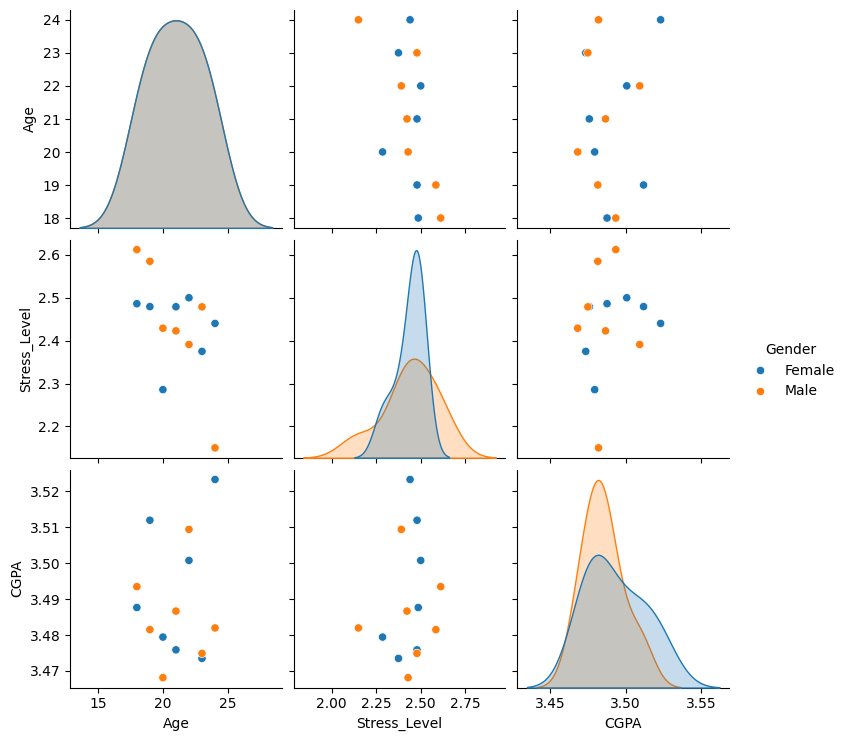

In [38]:
sns.pairplot(
    q1_df[['Age', 'Stress_Level', 'CGPA', 'Gender']],
    hue='Gender',
    diag_kind='kde'
)
plt.show()

**Methodology:**

Using a pairplot is a easy way to visualization the relationships between each variable. Doing this shows if the variables have any linear relationships with each other which is helpful when trying to find correlation.

**Findings:**

Looking at the diagonal plots above, the CPGA has a rather tight range for both genders mainly landing between 3.45 and 3.55. The stress_level plot shows a wider spread for males and a tighter spread for women, and age is completely overlapping. THe non-diagonal plots show no linear pattern between the variables which was expected from the findings in the above analysis.

In [39]:
#Q2
pivot_table = pd.pivot_table(
    q2_df,
    values=["CGPA", "Stress_Level", "mental_health_rating"],
    index="Sleep_Category",
    aggfunc="mean",
    observed=True
).round(2)

# Create mental health bands
q2_df["MH_Category"], mh_bins = pd.qcut(
    q2_df["mental_health_rating"],
    q=3,
    labels=["Low MH", "Medium MH", "High MH"],
    retbins=True
)

# Print the mental health ranges
print("Mental Health Category Bands:")
print("Low MH:", round(mh_bins[0], 2), "to", round(mh_bins[1], 2))
print("Medium MH:", round(mh_bins[1], 2), "to", round(mh_bins[2], 2))
print("High MH:", round(mh_bins[2], 2), "to", round(mh_bins[3], 2))

print("Pivot Table: Sleep Category vs CGPA, Stress, and Mental Health")
display(pivot_table)

Mental Health Category Bands:
Low MH: 5.03 to 5.14
Medium MH: 5.14 to 5.54
High MH: 5.54 to 6.18
Pivot Table: Sleep Category vs CGPA, Stress, and Mental Health


,CGPA,Stress_Level,mental_health_rating
Sleep_Category,,,
Low Sleep,3.48,2.48,5.62
Medium Sleep,3.50,2.46,5.27
High Sleep,3.49,2.37,5.28


**Methodology:**
I conducted multivariate analysis to examine the relationships between sleep, academic performance, stress, and mental health. I created a pivot table using sleep categories as the grouping variable and CGPA, stress level, and mental health rating as the outcome variables. This approach allowed for simulataneous comparison for multiple dependent variables across different levels of sleep. By aggregating mean values, the pivot table provides a clear summary of how these variables change across sleep categories. 

**Findings:**
The results show that CGPA remains consistent across all sleep categories, ranging from 3.48-3.50. This shows that sleep duration does not significantly impact academic performance.

Stress levels shows a noticeable pattern, decreaseing as sleep increases. Students in the high sleep category have the lowest average stress (2.37) compared to those in the low sleep category (2.48). This suggests that increased sleep is associated with reduced stress.

Mental health ratings show only small variation across sleep categories. Low sleep has the highest mental health rating (5.62), while medium and high sleep have similar values (5.27, 5.28). This suggests that the relationship between sleep and mental health is weak and not clearly defined in this dataset. 

The multivariate analysis suggests that sleep has a stronger relationship with stress than with academic performance or mental health, with CGPA remaining stable across all groups. 

In [40]:
#Q3

## Synthesis

#Q1

**Synthesis:**

By preforming multiple forms analysis on different subsets of stress vs CGPA it all resulted in no significant differences. Meaning that according to this data set, Gender and stress levels have no impact on a students CGPA. 

#Q2

**Synthesis:**

The analysis combined descriptive statistics, hypothesis testing, and graphs to examine the relationships between sleep, academic performance, stress levels and mental health. Across every method I used, CGPA remained stable regardless of sleep and study behaviors, while stress and mental health showed more variation.

**Insights:**

Descriptive statistics shows very little variation in CGPA across sleep categories and was reinforced by the ANOVA test results (p = 0.2015). Graphical analysis supported this finding by showing overlapping distributions and nearly identical averages across groups.

In contrast, visualizations and multivariate analysis revealed a consistent relationship between stress and sleep. Increased sleep was associated with slightly lower stress levels. This trend was visible in the scatter plots and confirmed in the pivot table, where stress decreased from low to high sleep categories. 

The integration of multiple datasets allowed for a more comprehensive analysis that would not have been possible by only using a single dataset. By combining behavioral data with outcome variables, we can examine performance and well-being simultaneously.

One dataset may have only show academic metrics or lifestyle. However, merging them allowed us to find key insights. These insights include findings like sleep and study habits have limited impact on academic performance but a more noticeable relationship on stress levels. 

The combined analysis suggests that while academic performance remains stable across different behaviors. However, lifestyle factors such as sleep play a more meaningful role in influencing stress, showing the importance of well-being alongside academic outcomes. 

#Q3

## Reflection

#Q1

Based on the analysis done towards question 1 (Do male and female students preform differently under high stress ?), all of the evidence points to the fact that there is little to relationship between a students gender, stress levels, and academic performance. The analysis was broken down multiple ways which included: a high stress subset, looking at the data overall with no gender separation, looking at the influence that age buckets had on the result, and splitting stress into 3 groups and seeing the influence that had on GPA. All of those results can back failing to reject HO and showing no clear relationship. Some of this could have been because one of our data sets is synthetic so it could not be representative of real life situations. Some of the numbers inputted can have no clear associations or thought behind it making this analysis difficult and non-representative. I would like to repeat this portion of the analysis with real student data because I believe the results could be different.

#Q2

**Reflection:**

The goal of my analysis was to examine how sleep influences academic performance. Across all sleep categories, CGPA remained consistent, and the ANOVA test confirmed that these differences were not significant. However, sleep showed a more noticeable relationship with stress levels, as students with higher sleep tended to report lower stress.

**Challenges:**

One of the main challenges was making sure that all of the variables matched. Having to match columns names and align datasets took me a minute. Another challenge that I had to overcome was making categorical variables for numerical data. This categorical data was the sleep quality that we saw and the mental health ratings that we saw as well. I went about this by splitting the data into three equal groups, where each group has the same number of observations and then assigning labels to them. 

**Limitations:** 

I felt like there were several limitations to this type of analysis. First, there is really low variability in the CGPA, which will make it difficult to find trends and strong relationships. Next, I do feel like my use of categorical groupings may have oversimplified the data and is masking more subtle relationships. Furthermore, our analysis is based on observational data. While we see may see a relationship between sleep and lower stress, it cannot be concluded that more sleep causes reduced stress. 

#Q3